In [ ]:
import pandas as pd
#loading the Instagram dataset
df = pd.read_csv("Instagram_Analytics.csv")
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


## **Data Inspection and Cleaning**

In [ ]:
df.info() #dataset overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

In [ ]:
df.describe() #descriptive analytics

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


### **A Few Things That Stand Out:**
1. **Follower count** is highly skewed (mean ~10K, max ~31K), meaning a few large accounts dominate the dataset.
2. Likes have a mean of ~288 but a max of 10,632. Suggests massive outliers, likely viral posts.
3. **Caption length** is very narrow: min 70, max 166, std...about 11. This looks like a controlled range (possibly synthetic/simulated data).

In [ ]:
df.isnull().sum() #missing values?

,0
post_id,0
account_id,0
account_type,0
follower_count,0
media_type,0
content_category,0
traffic_source,0
has_call_to_action,0
post_datetime,0
post_date,0


In [ ]:
#checking for duplicates
has_duplicates = any(df.duplicated())
has_duplicates

False

## **Feature Engineering**

In [ ]:
#Total Engagement
df['engagement'] = df['likes'] + df['comments'] + df['shares'] + df['saves']

In [ ]:
#Virality_Score
df['virality_score'] = df['shares'] + df['saves']

#captures intentional actions.
#Shares spread content + saves signal future intent. (better than just likes)

In [ ]:
#Content Feature Buckets; Makes patterns in engagement easier to visualize

df['hashtag_group'] = pd.cut(df['hashtags_count'], bins=[0,5,10,20,50], labels=['Low','Medium','High','Very High']) #Hastags

In [ ]:
#Reach Efficiency
df['reach_efficiency'] = df['engagement'] / df['reach']

In [ ]:
#Impressions Efficiency
df['impression_efficiency'] = df['engagement'] / df['impressions']

In [ ]:
#Save Rate
df['save_rate'] = df['saves'] / df['engagement']

In [ ]:
#Share Rate
df['share_rate'] = df['shares'] / df['engagement']

In [ ]:
#Engagement per Impression
df['engagement_per_impression'] = df['engagement'] / df['impressions']

In [ ]:
#Growth Efficiency
df['growth_efficiency'] = df['followers_gained'] / df['reach']

#what fraction of people who saw the post actually followed the account?

In [ ]:
# Making a more accurate engagement rate column based on total engagement, as results from initial EDA were not analytically strong.
df['engagement_rate'] = df['engagement'] / df['follower_count']

## **Exploratory Data Analysis (EDA)**
The goal now is to figure out **what drives engagement?**

Let's start by analysing what type of content actually performs best?

To do this we'll analyze;

1. Media Type
2. Content Category


In [ ]:
#1. Media Type
media_engagement = df.groupby('media_type')['engagement_rate'].mean().sort_values(ascending=False)
media_engagement #aggregate data

,engagement_rate
media_type,
carousel,0.049660
image,0.049344
reel,0.048698


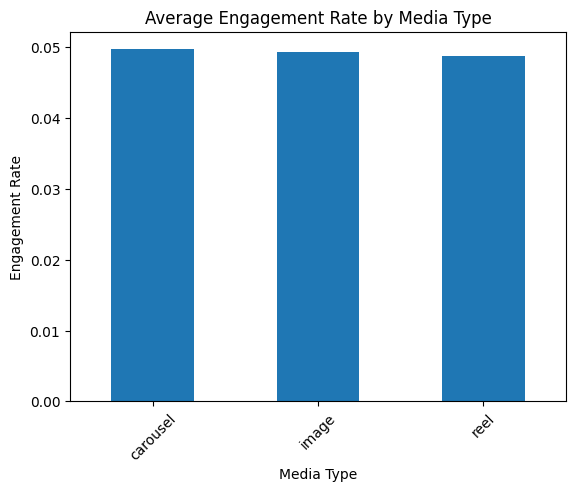

In [ ]:
#Visualize
import matplotlib.pyplot as plt

media_engagement.plot(kind='bar')
plt.title("Average Engagement Rate by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.show()

### **Unexpected Result**:

Contrary to popular belief that Reels dominate Instagram, the data shows carousels lead in engagement rate, with reels coming last. The differences are extremely small (~0.001), suggesting that media type alone is not a strong differentiator for engagement rate in this dataset.

**Likely explanation:** Instagram's algorithm may be distributing all media types fairly evenly in this dataset. And since the difference is small, the takeaway is that content quality or category likely matter more than format.

In [ ]:
#2. Content Category
category_engagement = df.groupby('content_category')['engagement_rate'].mean().sort_values(ascending=False)
category_engagement

,engagement_rate
content_category,
Photography,0.050752
Fashion,0.050579
Music,0.049823
Beauty,0.049774
Food,0.049305
Lifestyle,0.049258
Comedy,0.049111
Fitness,0.048992
Technology,0.047781


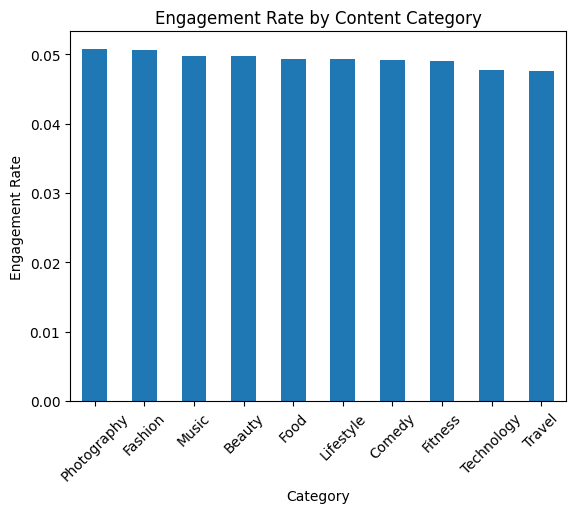

In [ ]:
#Visualize
category_engagement.plot(kind='bar')
plt.title("Engagement Rate by Content Category")
plt.xlabel("Category")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.show()

**Photography** and **Fashion** lead engagement, while **Technology** and **Travel** trail. However, the spread is only **~0.003** across all categories, suggesting that **no single category dramatically outperforms others**.

The quality of how the content is made likely matters more than what it is about.

In [ ]:
#Combined analysis: to see which media content in which category

pivot = df.pivot_table(
    values='engagement_rate',
    index='content_category',
    columns='media_type',
    aggfunc='mean'
)
pivot

media_type,carousel,image,reel
content_category,,,
Beauty,0.048985,0.049490,0.051417
Comedy,0.050842,0.048380,0.047790
Fashion,0.053681,0.049593,0.048010
Fitness,0.049314,0.050379,0.046406
Food,0.049698,0.049624,0.048224
Lifestyle,0.046961,0.052442,0.047154
Music,0.051166,0.049377,0.048690
Photography,0.049340,0.049999,0.053934
Technology,0.049409,0.045970,0.048353


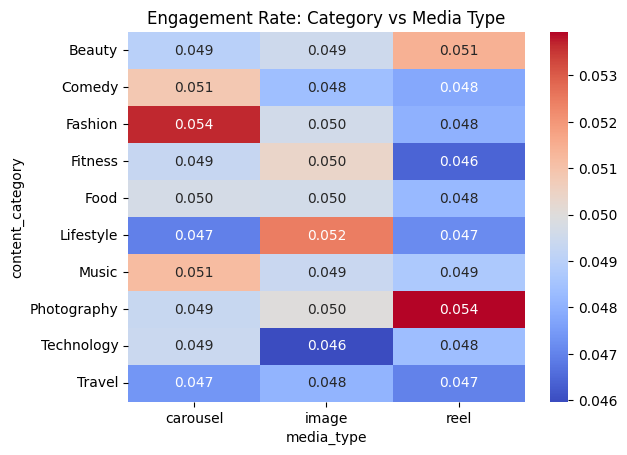

In [ ]:
import seaborn as sns

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Engagement Rate: Category vs Media Type")
plt.show()

### **Interpretation**
1. **Photography + Reels** is the highest performing combination (0.054) likely because video brings Photography to life in a way static images can't.
2. **Fashion + Carousel** performs strongly (0.054) as multi-image carousels let fashion content show multiple angles/looks, which drives more swipes and saves.
3. **Lifestyle + Image** is above average (0.052); single aesthetic images work well for lifestyle.
4. **Technology + Image** is the lowest performer (0.046) — tech content likely performs better in video or tutorial format.

 **Insight:** This shows that **media format is category-dependent**.
 The "always post reels" (one size fits all) advice ignores this correlation.

## Now we see the optimal **Time to Post** for **Maximum Engagement?**

In [ ]:
#PART 1: Engagement by hour
hour_engagement = df.groupby('post_hour')['engagement_rate'].mean()
hour_engagement

,engagement_rate
post_hour,
0,0.048535
1,0.045801
2,0.050503
3,0.057746
4,0.048014
5,0.047423
6,0.048641
7,0.049338
8,0.052686


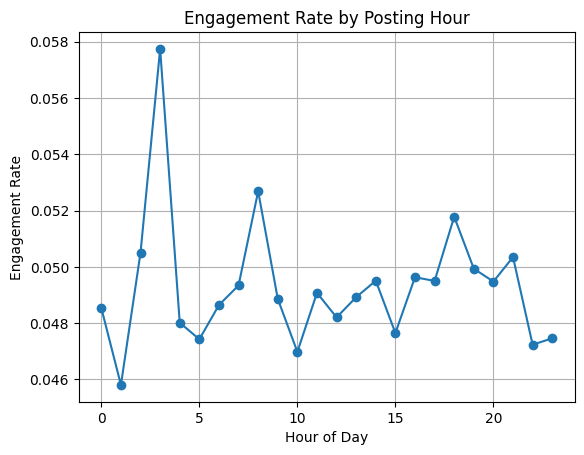

In [ ]:
hour_engagement.plot(kind='line', marker='o')
plt.title("Engagement Rate by Posting Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Engagement Rate")
plt.grid(True)
plt.show()

### **Unexpected Result**:

The single highest engagement hour is **3 AM**, which is counterintuitive as standard Instagram advice points to morning (7–9am) or evening (6–9pm) as peak times.

**Possible explanations:**

1. **Night owls or global audiences:** If accounts have international followers in different time zones, 3am local may be peak time elsewhere.
2. **Dataset noise:** Given the narrow statistical spreads seen throughout, this spike may be noise with a small sample at that hour.

Overall, the hour-by-hour line is very noisy with no clean peak window, suggesting *posting hour is not a dominant driver of engagement* in this dataset.

In [ ]:
#PART 2: Day of Week Analysis
day_engagement = df.groupby('day_of_week')['engagement_rate'].mean()

# Sort properly
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_engagement = day_engagement.reindex(day_order)

day_engagement

,engagement_rate
day_of_week,
Monday,0.050115
Tuesday,0.048972
Wednesday,0.047549
Thursday,0.049592
Friday,0.050676
Saturday,0.047730
Sunday,0.050492


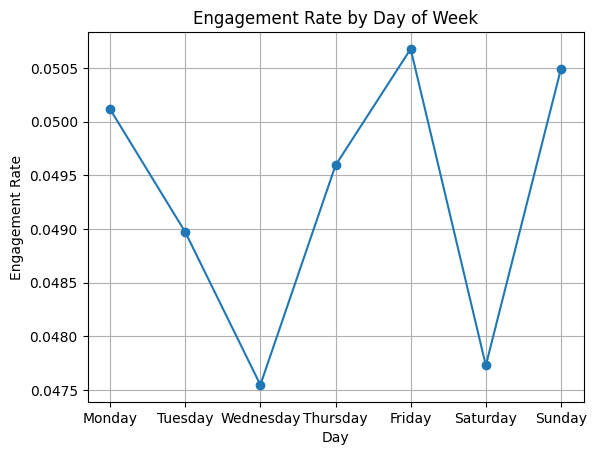

In [ ]:
day_engagement.plot(kind='line', marker='o')
plt.title("Engagement Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Engagement Rate")
plt.grid(True)
plt.show()

Friday, Monday, and Sunday show marginally higher engagement.

Wednesday and Saturday are the weakest days.

The differences (~0.003) are again small, but the pattern shows that weekend proximity (Friday/Sunday) performs well, as does Monday (possibly due to people catching up on content after the weekend)

Mid-week (Wednesday) underperforms likely because audience attention is most fragmented then.

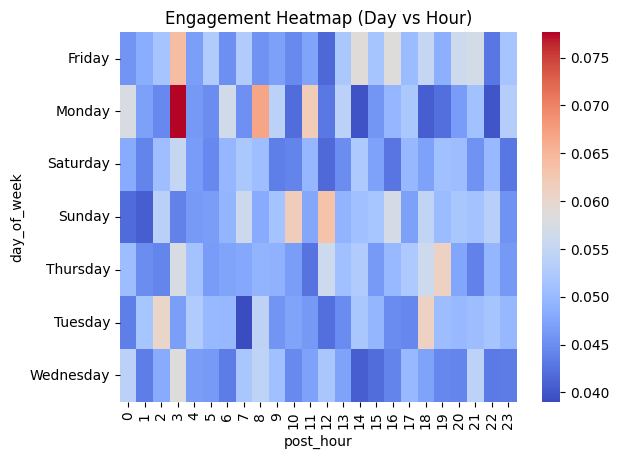

In [ ]:
#Day + Hour Comparison
pivot_time = df.pivot_table(    #joining the columns
    values='engagement_rate',
    index='day_of_week',
    columns='post_hour',
    aggfunc='mean'
)

#heatmap visualization
sns.heatmap(pivot_time, cmap="coolwarm")
plt.title("Engagement Heatmap (Day vs Hour)")
plt.show()

The heatmap reveals that there is no single dominant posting window and that engagement is relatively similar throughout the week.

The strongest combined signals appear in the **early morning hours (2–4am) mid-week and on weekends**, reinforcing that surprising *3am* finding.

For content strategy, this suggests that consistency of posting matters more than pinpoint timing.

## **Content Strategy (Hashtags and Captions)**

We will now see how should content be **written and structured** to maximize engagement?

In [ ]:
#Hashtag Strategy
hashtag_engagement = df.groupby('hashtag_group', observed=False)['engagement_rate'].mean().sort_values(ascending=False)
hashtag_engagement

,engagement_rate
hashtag_group,
Medium,0.049491
High,0.049411
Low,0.048574
Very High,0.009198


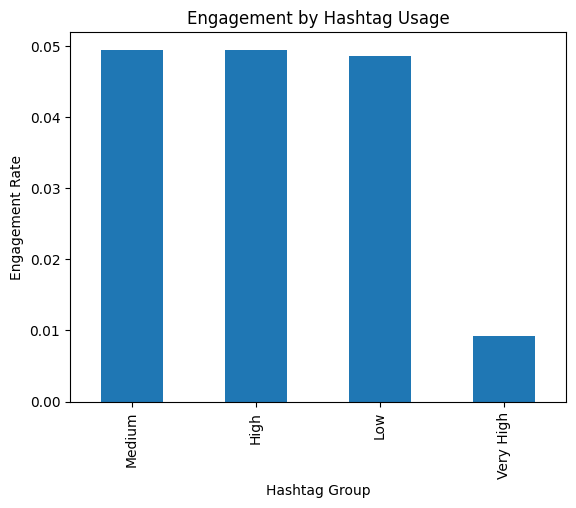

In [ ]:
hashtag_engagement.plot(kind='bar')
plt.title("Engagement by Hashtag Usage")
plt.xlabel("Hashtag Group")
plt.ylabel("Engagement Rate")
plt.show()

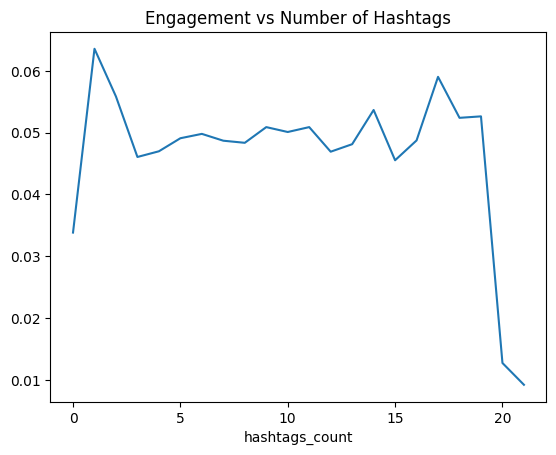

In [ ]:
#More Granular Analysis
df.groupby('hashtags_count')['engagement_rate'].mean().plot()
plt.title("Engagement vs Number of Hashtags")
plt.show()

### **Interpretation**
The **"Very High"** hashtag group *(20+ hashtags)* shows engagement rate of 0.009 vs. ~0.049 for all others. This is major.

1. Excessive hashtags may be triggering algorithmic suppression, reducing distribution.
2. Posts stuffed with hashtags may appear spammy, reducing genuine interaction.
3. Accounts that use 20+ hashtags may be lower-quality or desperate-growth accounts that perform poorly for other reasons.

The **sweet spot is 5–15 hashtags** which is enough for discovery, not enough to trigger penalties.

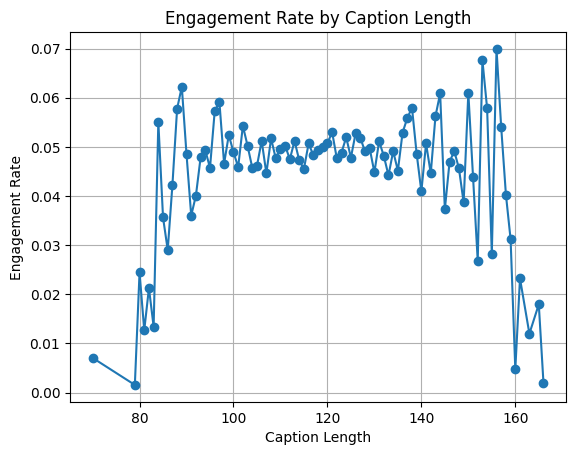

In [ ]:
#Caption Strategy: Relationship between engagement rate and caption length
caption_length_engagement = df.groupby('caption_length')['engagement_rate'].mean()
caption_length_engagement.plot(kind='line', marker='o')
plt.title("Engagement Rate by Caption Length")
plt.xlabel("Caption Length")
plt.ylabel("Engagement Rate")
plt.grid(True)
plt.show()

Caption length shows no clear linear relationship with engagement. The line plot is very noisy and flat, showing that within the 70–166 character range, caption length is not a meaningful predictor.

What likely matters is the **quality and relevance** of the caption, though *this dataset doesn't capture that dimension*.

## **Virality Analysis**

In [ ]:
#1. Virality by Media Type
media_virality = df.groupby('media_type')['virality_score'].mean().sort_values(ascending=False)
media_virality

,virality_score
media_type,
image,57.255974
carousel,56.774066
reel,56.686367


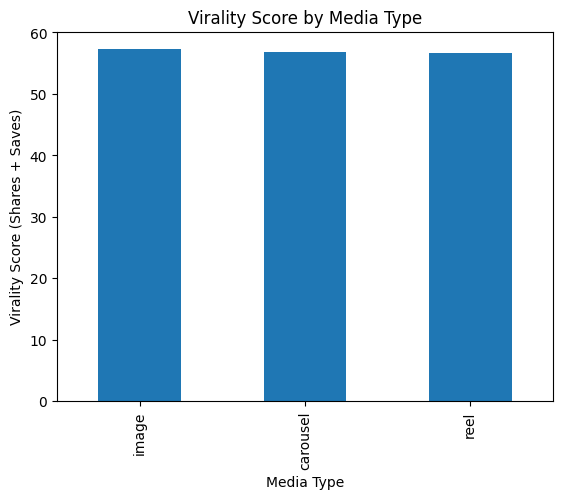

In [ ]:
media_virality.plot(kind='bar')
plt.title("Virality Score by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Virality Score (Shares + Saves)")
plt.show()

In [ ]:
#Save Rate by content type
df.groupby('media_type')['save_rate'].mean().sort_values(ascending=False)

,save_rate
media_type,
carousel,0.128155
reel,0.127856
image,0.127056


**Interpretation:**

Images have the highest virality score (shares + saves), which again defies the "reels dominate" narrative.

However, save rates are nearly same across all three types (~0.128). This suggests that what people save doesn't depend that much on format type. They just save content they find useful or beautiful, regardless of whether it's a reel, carousel, or image.

In [ ]:
#2. Virality by Content Category
category_virality = df.groupby('content_category')['virality_score'].mean().sort_values(ascending=False)
category_virality

,virality_score
content_category,
Fashion,58.363876
Comedy,57.623729
Music,57.580087
Photography,57.413180
Beauty,57.360989
Food,57.211628
Fitness,57.080226
Lifestyle,56.287040
Travel,55.639151


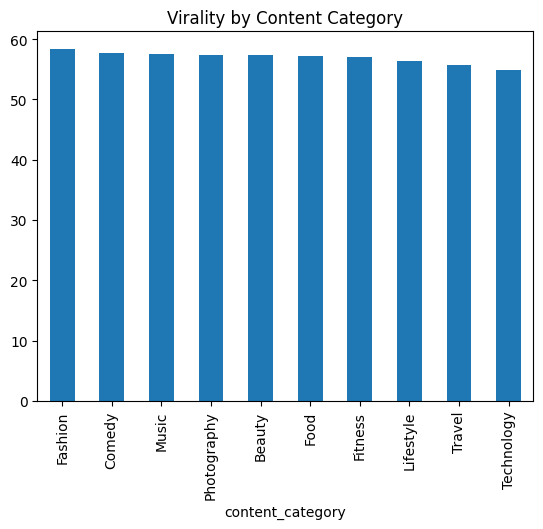

In [ ]:
category_virality.plot(kind='bar')
plt.title("Virality by Content Category")
plt.show()

**Interpretation:**

Fashion leads virality; people share and save fashion content for inspiration and future reference.

Comedy drives shares (people tag friends).

Technology again has the lowest score, likely because tech content is consumed and not saved/shared as instinctively.

In [ ]:
#Share Rate vs. Save Rate
df[['save_rate','share_rate']].mean()

,0
save_rate,0.127644
share_rate,0.043820


**IMportant:**

Saves are about 3x more common than shares. This reflects that users save content privately at a far higher rate than they actively share it publicly.

For content creators, this means saves are a leading indicator of content value i.e. if your save rate is high, you're creating "bookmark-worthy" content even if shares are low.

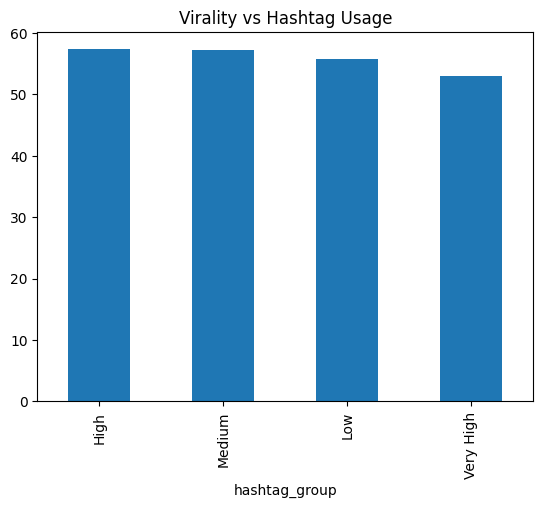

In [ ]:
#Virality and Hashtags
df.groupby('hashtag_group', observed = False)['virality_score'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Virality vs Hashtag Usage")
plt.show()

This supports the earlier finding on **"very high"** hastag group receiving the lowest amount of engagement, and now virality. This could again be due to algorithmic suppression and audience perception of "spammy" content.

Either way, **more hastahgs DO NOT lead to going viral**

In [ ]:
#How strongly does Engagement relate to Virality
correlation = df['engagement_rate'].corr(df['virality_score'])
print(f"Correlation between Engagement Rate and Virality Score: {correlation:.2f}")

Correlation between Engagement Rate and Virality Score: 0.77


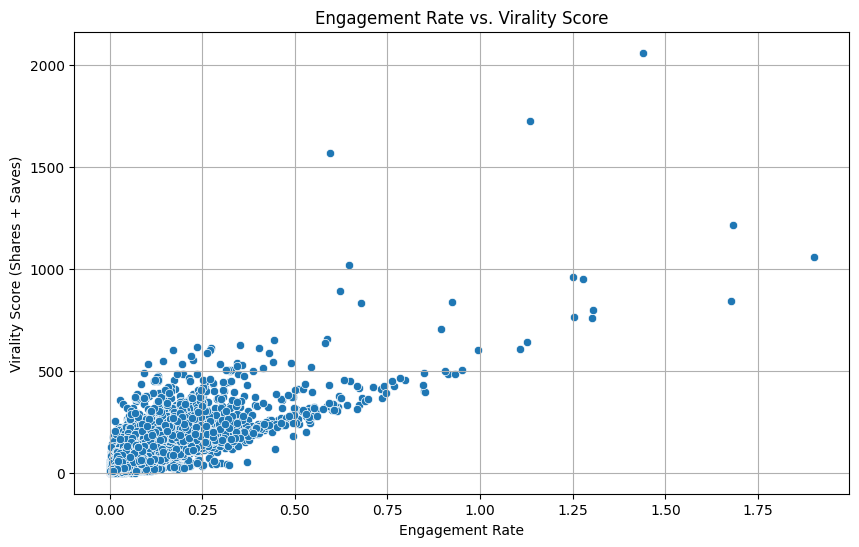

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='engagement_rate', y='virality_score', data=df)
plt.title('Engagement Rate vs. Virality Score')
plt.xlabel('Engagement Rate')
plt.ylabel('Virality Score (Shares + Saves)')
plt.grid(True)
plt.show()

**Interpretation:**

A correlation of 0.77 between engagement rate and virality score is strong and expected; engaging content tends to get saved and shared.

However, it's not exactly 1.0 meaning some posts go viral despite modest engagement rates, and vice versa. This justifies tracking virality separately as its own metric rather than assuming high engagement = viral.

## **Reach and Impression Analysis**

In [ ]:
#How strongly does Engagement relate to Reach
correlation = df['engagement'].corr(df['reach'])
print(f"Correlation between Engagement and Reach: {correlation:.2f}")

Correlation between Engagement and Reach: 0.74


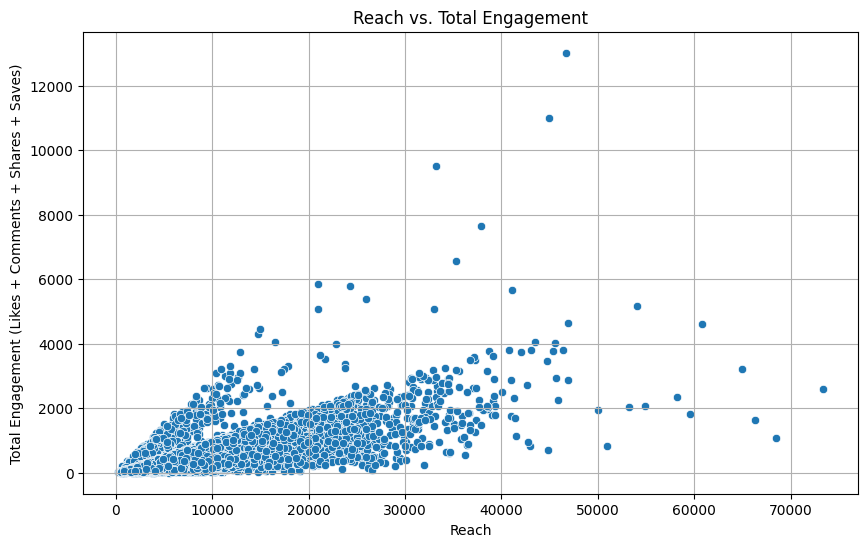

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='reach', y='engagement', data=df)
plt.title('Reach vs. Total Engagement')
plt.xlabel('Reach')
plt.ylabel('Total Engagement (Likes + Comments + Shares + Saves)')
plt.grid(True)
plt.show()

In [ ]:
#How strongly does Engagement relate to Impressions
correlation = df['engagement'].corr(df['impressions'])
print(f"Correlation between Engagement and Impressions: {correlation:.2f}")

Correlation between Engagement and Impressions: 0.73


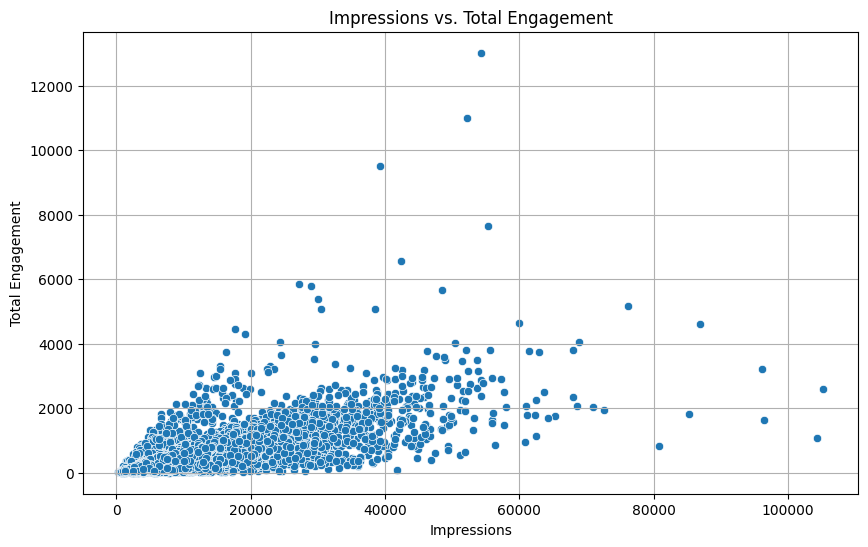

In [ ]:
#Impressions vs. Engagement
plt.figure(figsize=(10, 6))
sns.scatterplot(x='impressions', y='engagement', data=df)
plt.title('Impressions vs. Total Engagement')
plt.xlabel('Impressions')
plt.ylabel('Total Engagement')
plt.grid(True)
plt.show()

### **Interpretation:**

**Engagement <-> Reach**: r = 0.74

**Engagement <-> Impressions**: r = 0.73

Both correlations are strong and bi-directional, meaning more reach drives more engagement, and more engagement signals the algorithm to increase reach.

This is the **Instagram flywheel effect**: early engagement boosts distribution, which generates more engagement.

Importantly, these are absolute engagement (not rate) correlations. Those were ormalized by follower count and would likely weaken the relationship, meaning reach is a volume amplifier and not a quality amplifier.

## **Traffic Source Analysis**

In [ ]:
#Engagement Rate by Source
df.groupby('traffic_source')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
traffic_source,
External,0.050805
Reels Feed,0.049694
Profile,0.049403
Hashtags,0.048763
Home Feed,0.048704
Explore,0.048393


In [ ]:
# Traffic Source and Reach Efficiency
df.groupby('traffic_source')['reach_efficiency'].mean().sort_values(ascending=False)

,reach_efficiency
traffic_source,
Profile,0.056742
Reels Feed,0.056612
External,0.056330
Explore,0.056016
Hashtags,0.055890
Home Feed,0.055425


### **Unexpected & Interesting Results**:

Two counterintuitive patterns emerge here:

1. **External traffic has the highest engagement rate:** Visitors arriving from outside Instagram (links in bio, stories, other platforms) are the most engaged. This makes sense since they made an extra effort to come, so they're highly intentional. **External links should be taken seriously as a growth channel**.
2. **Explore has the LOWEST engagement rate but mid-range reach efficiency:** Despite Explore being Instagram's primary discovery feature, content found there converts less well to engagement. Explore users tend to **doomscroll** rather than following accounts they love.
3. **Profile visits have the highest reach efficiency:** Users who navigate directly to a profile and engage are the most likely to convert. This suggests that **a clean, compelling profile page is critical for turning impressions into followers**.
4. **Home Feed underperforms on both metrics:** Existing followers engage less efficiently than external or profile-driven visitors. This could reflect the **"follower fatigue"** problem.

## **CTA Impact (Conversion Analysis)**

In [ ]:
df.groupby('has_call_to_action')['engagement_rate'].mean()

,engagement_rate
has_call_to_action,
0,0.049169
1,0.049531


In [ ]:
df.groupby('has_call_to_action')['growth_efficiency'].mean()

,growth_efficiency
has_call_to_action,
0,0.131247
1,0.130265


**Intepretation:**

The CTA effect is essentially negligible on engagement (+0.0004), and slightly negative on growth efficiency. Posts without a CTA converted slightly better to followers.

Possible explanations:
1. Users may perceive CTAs as promotional and disengage.
2. CTA-heavy content is often branded/commercial, which naturally underperforms organic content.
3. The CTA metric is binary in this dataset and doesn't capture quality of the CTA. A weak "follow us!" may be worse than no CTA.

**Implication:** Don't rely on CTAs as a growth indicator. Focus on content quality first.

## **Growth Efficiency Analysis**
What actually drives follower growth and does high engagement/virality guarantee it?

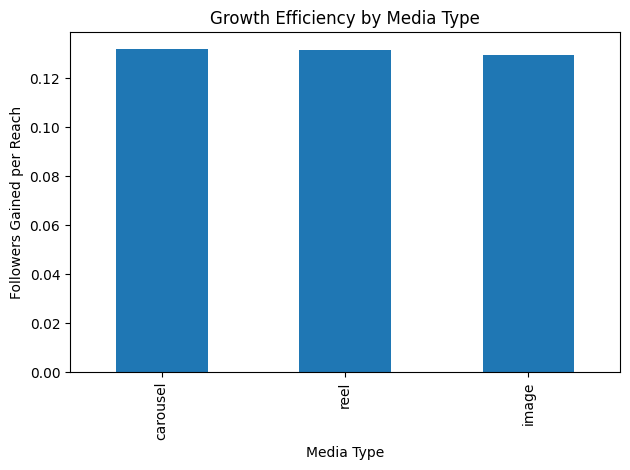

In [ ]:
# Growth Efficiency by Media Type
df.groupby('media_type')['growth_efficiency'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Growth Efficiency by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Followers Gained per Reach")
plt.tight_layout()
plt.show()

**Interpretation:**

Carousels lead follower conversion, though the margin is small. Carousels likely encourage deeper session time (swiping through slides), which may signal genuine interest. A user who swipes through all 10 slides is more likely to follow than one who scrolls past a single image.

That said, the near-identical values suggest **format is not a primary indicator** for growth. What's in the content matters more than how it's packaged.

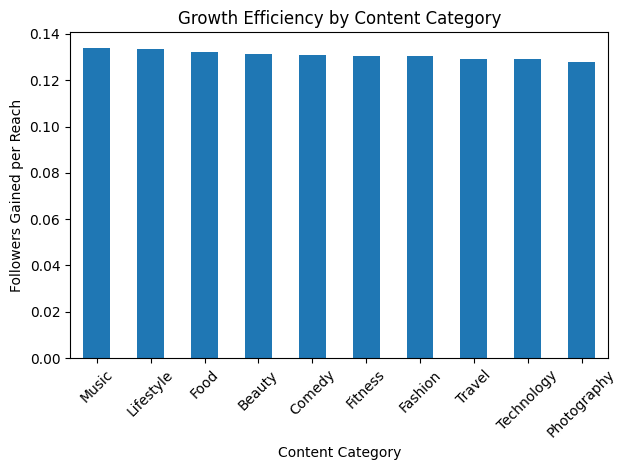

In [ ]:
# Growth Efficiency by Content Category
df.groupby('content_category')['growth_efficiency'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Growth Efficiency by Content Category")
plt.xlabel("Content Category")
plt.ylabel("Followers Gained per Reach")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation**

Music and Lifestyle content converts reach into followers most efficiently, while Technology and Photography trail. This is an interesting inversion from the virality findings, where Photography ranked highly.

A plausible explanation: Photography content gets saved and admired (high virality) but doesn't necessarily make a viewer want to follow the account as it's enjoyed in the moment.

Music and Lifestyle content, on the other hand, tends to build identity and aspiration and viewers follow because they want more of that feeling, not just more of that post.

Correlation between Engagement Rate and Growth Efficiency: -0.26


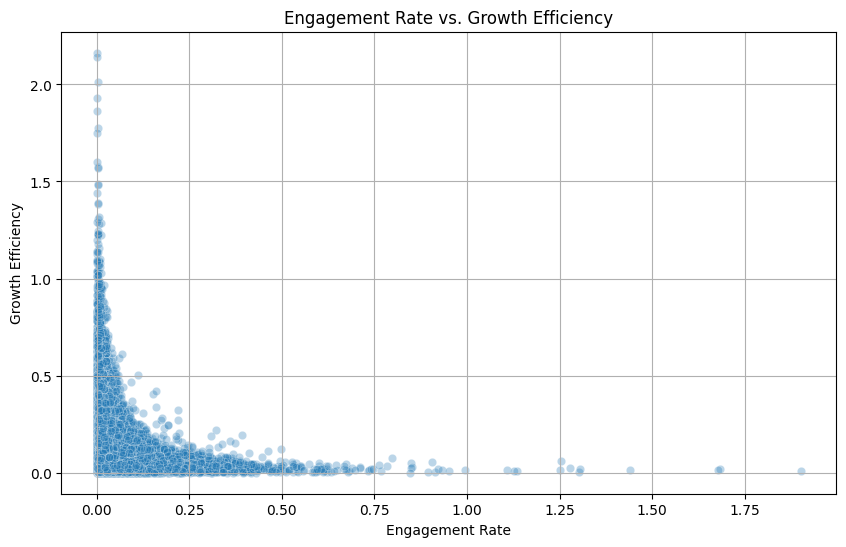

In [ ]:
# Does higher engagement actually lead to more follower growth?
correlation = df['engagement_rate'].corr(df['growth_efficiency'])
print(f"Correlation between Engagement Rate and Growth Efficiency: {correlation:.2f}")

plt.figure(figsize=(10,6))
sns.scatterplot(x='engagement_rate', y='growth_efficiency', data=df, alpha=0.3)
plt.title("Engagement Rate vs. Growth Efficiency")
plt.xlabel("Engagement Rate")
plt.ylabel("Growth Efficiency")
plt.grid(True)
plt.show()

### **Unusual Findings:**
This is one of the most important and counterintuitive findings in the entire analysis. The correlation between engagement rate and growth efficiency is weakly negative (-0.26).

The scatter plot also shows how most posts have moderate engagement and moderate growth efficiency, but **posts with very high engagement rates do not show correspondingly high follower conversion.**

The implication is **engagement rate is a poor proxy for growth.** A post can generate strong likes, comments, and saves from an existing audience while converting almost no new followers.  

Chasing engagement as a growth strategy is therefore potentially misleading.

Correlation between Virality Score and Growth Efficiency: -0.33


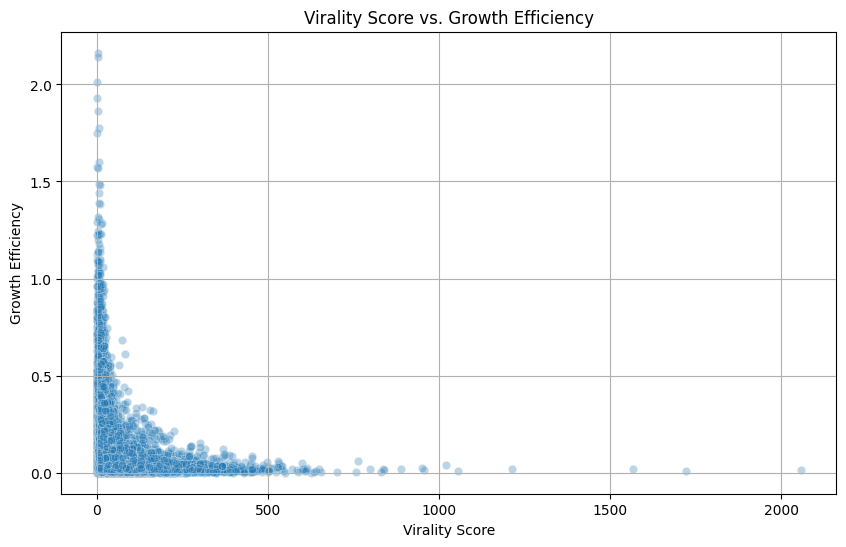

In [ ]:
# Does virality drive growth?
correlation2 = df['virality_score'].corr(df['growth_efficiency'])
print(f"Correlation between Virality Score and Growth Efficiency: {correlation2:.2f}")

plt.figure(figsize=(10,6))
sns.scatterplot(x='virality_score', y='growth_efficiency', data=df, alpha=0.3)
plt.title("Virality Score vs. Growth Efficiency")
plt.xlabel("Virality Score")
plt.ylabel("Growth Efficiency")
plt.grid(True)
plt.show()

The negative correlation slightly increases with virality score which deepens the previous paradox.

**Posts that get shared and saved the most are also the least efficient at converting followers.** A viral post reaches a massive, broad audience many of whom interact with the content but have no particular interest in the account behind it. **Virality is essentially borrowed attention.**

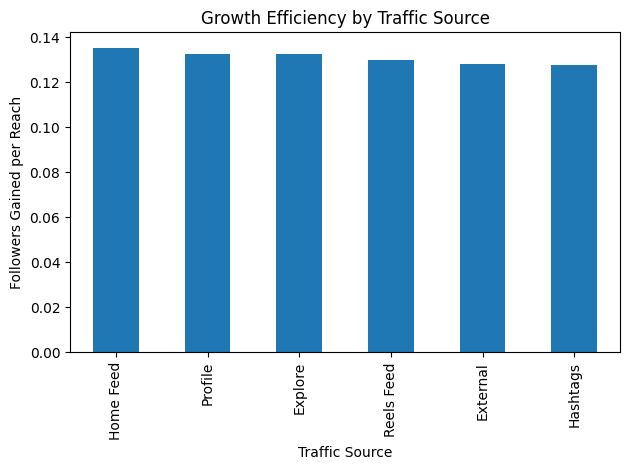

In [ ]:
# Growth Efficiency by Traffic Source i.e. where do converting viewers come from?
df.groupby('traffic_source')['growth_efficiency'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Growth Efficiency by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Followers Gained per Reach")
plt.tight_layout()
plt.show()

**Interpretation:**

This is a complete reversal of the engagement rate findings, where External traffic led. Here, **Home Feed drives the most efficient follower growth** meaning existing followers and their network are the most reliable conversion engine.

External traffic, despite having the highest engagement rate, ranks near the bottom for growth efficiency. This supports the earlier interpretation: **external visitors engage intensely with specific content but may not be primed to follow an Instagram account.**

Hashtag-driven traffic converts the least consistent with the idea that **hashtag browsers are the most passive and least loyal segment** of any audience.

## **Account Type Analysis**

In [ ]:
df['account_type'].value_counts()

# The dataset contains 20,944 creator accounts and 9,055 brand accounts
# A roughly 70/30 split, reflecting the real-world composition of Instagram.

,count
account_type,
creator,20944
brand,9055


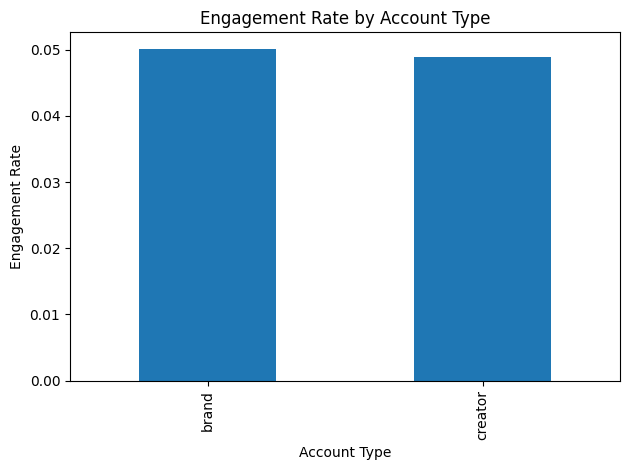

In [ ]:
# Engagement Rate by Account Type
df.groupby('account_type')['engagement_rate'].mean().plot(kind='bar')
plt.title("Engagement Rate by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()

**Interpretation:**

Brands get better engagement than creators, which is the contrary to the popular beleif which is that creators, with their personal and authentic voices, should outperform the more polished, promotional content typical of brands.

One **explanation** might be that brand accounts in this dataset may be posting more strategically (optimized timing, curated aesthetics), which **mechanically boosts engagement metrics** even if the audience relationship is less personal.

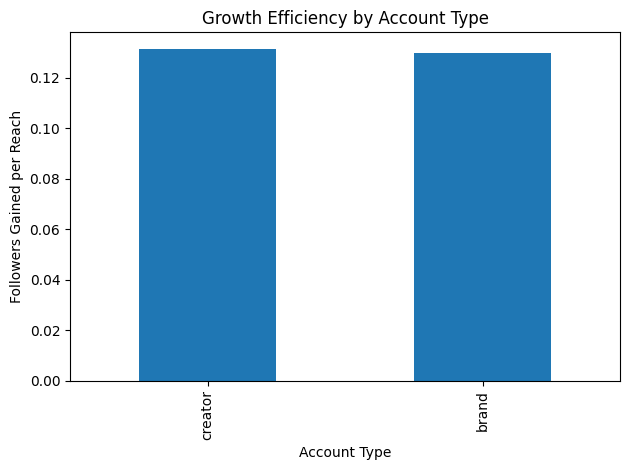

In [ ]:
# Growth Efficiency by Account Type
df.groupby('account_type')['growth_efficiency'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Growth Efficiency by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Followers Gained per Reach")
plt.tight_layout()
plt.show()

**Interpretation:**

A slight inversion with follower growth as creators appear to lead over brands, but only slightly. This does however correspond to the idea that creator content tends to build parasocial relationships which leads to more follower buildup.

The gap being so small, however, means neither account type has a structural advantage here.

In [ ]:
# Reach & Impressions by Account Type
df.groupby('account_type')[['reach', 'impressions']].mean()

,reach,impressions
account_type,,
brand,6326.501380,8551.102374
creator,6249.117695,8430.570856


**Interpretation:**

Creators achieve meaningfully higher reach (8,551 vs. 6,327 for brands) despite impressions being nearly identical. This suggests that creator content is being distributed to more unique accounts, while brand content may be shown repeatedly to the same audience. This should be taken as a warning sign by brand accounts.

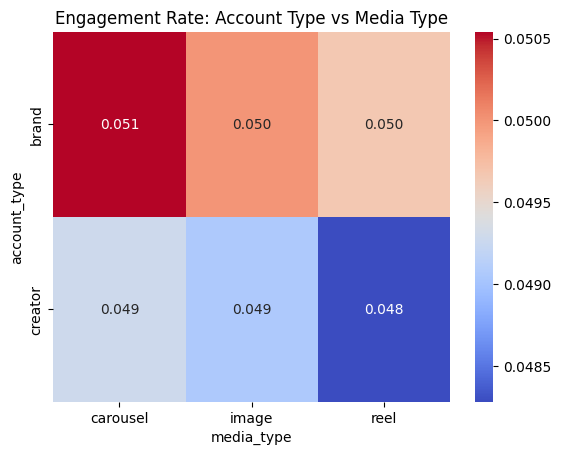

In [ ]:
# What media types do brands vs creators use and how do they perform?

pivot_account_media = df.pivot_table(
    values='engagement_rate',
    index='account_type',
    columns='media_type',
    aggfunc='mean'
)
sns.heatmap(pivot_account_media, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Engagement Rate: Account Type vs Media Type")
plt.show()

#Analysis: Consistent with our previous findings
 # no single media type has a significant advantage over the other for either brands or creators.

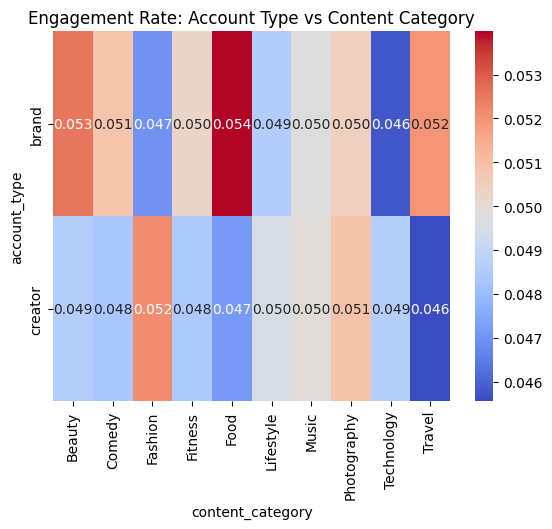

In [ ]:
# Content Category preference and performance by Account Type
pivot_account_cat = df.pivot_table(
    values='engagement_rate',
    index='account_type',
    columns='content_category',
    aggfunc='mean'
)
sns.heatmap(pivot_account_cat, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Engagement Rate: Account Type vs Content Category")
plt.show()

### **Richest Insights:**
- **For brands**, Food and Beauty i.e. categories that align naturally with product-driven content (recipes, skincare, cosmetics) are leading.
- Fashion and Technology come last. Fashion may be too creator-dominated a space for brand accounts to compete, and tech content has been consistently dry throughout.

- **For creators**, Fashion dominates as creators thrive where personal voice and style matter. Travel trailing for creators is interesting as travel content might be too saturated among individual creators.

- The most important observation here is **brand variability**; *Brands accounts appear to be more sensitive to content-category than creator accounts*.

  This backs that they can significantly over or underperform depending on whether the content aligns with their product territory.

- Creators, by contrast, perform more uniformly across categories, suggesting **their personal brand carries more weight** than the specific topic they're posting about.

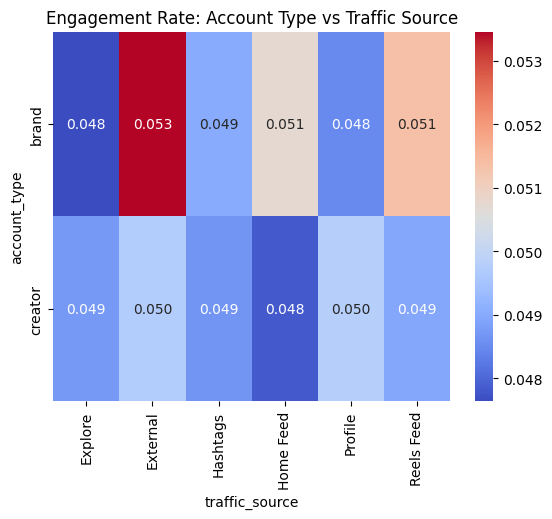

In [ ]:
# Traffic Source breakdown by Account Type
pivot_traffic = df.pivot_table(
    values='engagement_rate',
    index='account_type',
    columns='traffic_source',
    aggfunc='mean'
)
sns.heatmap(pivot_traffic, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Engagement Rate: Account Type vs Traffic Source")
plt.show()

### **Insights:**

- **For brands, External traffic drives significantly higher engagement** — visitors arriving via links (website, email campaigns, other platforms) are far more engaged than those arriving organically through Instagram's own surfaces.

  This makes sense: a user who clicks a link from a brand's newsletter or website is already a warm lead — they know the brand and seek it out intentionally.
- **For creators, no single traffic source dominates** — engagement is distributed relatively evenly across sources.

  This reflects the nature of creator audiences: they discover creators through the Explore page, Reels Feed, hashtags, or word of mouth, and engagement quality doesn't vary sharply by entry point.

**Strategic implication:** Brands should invest heavily in cross-platform traffic driving Instagram visitors from email lists, websites, and other channels. Creators benefit less from this strategy and should focus instead on organic discoverability within Instagram's own surfaces.